In [50]:
from pathlib import Path
import gzip
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from stable_platform_matchings.domain.instance import Instance
import seaborn as sns
from matplotlib.ticker import FuncFormatter

In [51]:
sns.set_theme(context="paper", style="ticks")

In [52]:
root = Path("../results/exp_6")
all_jsons = list(root.rglob("*.json.gz"))
graph_data_filename = "../data/graph_0-14960_00_new.pickle"
instance = Instance.from_yaml(Path('../data/anon_14_day_instances/2020-08-27.yaml'))

In [53]:
LC_TO_USD = instance.lc_to_usd
TRUCK_FIXED_COST = instance.truck_fixed_cost

MAX_DEVIATION_POTENTIAL = 12

DEV_POT_BINS = np.linspace(2, 12, 7)
COST_BINS = np.linspace(65, 110, 7)

ZERO_TOL = 1e-8


def currency_formatter(x, pos):
    return f"${x:.0f}"


plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})


In [54]:
data = []

for file in all_jsons:
    with gzip.open(file, "rt", encoding="utf-8") as f:
        aggregate_payload = json.load(f)

    job_id = aggregate_payload["job_id"]

    for payload in aggregate_payload["runs"]:
        n_hist_sets = payload["metadata"]["n_hist_sets"]

        instance_snapshot = payload["summary_naive"]["instance_snapshot"]
        instance_id = instance_snapshot["instance_id"]

        het_costs = payload["sampled_inputs"]["het_costs"]
        intermediaries = instance_snapshot["intermediaries"]


        total_quantity = sum(
            farmer["quantity"] for farmer in instance_snapshot["farmers"]
        )

        total_fruit_value = total_quantity * instance.fruit_price_per_ton

        naive_result = payload["summary_naive"]["platform_solve_result"]
        primary_naive_result = naive_result["primary_result"]
        naive_platform_profit = primary_naive_result["platform_profit"]

        scaled_root_result = payload["summary_scaled_root"]["platform_solve_result"]
        primary_scaled_root_result = scaled_root_result["primary_result"]
        scaled_root_platform_profit = primary_scaled_root_result["platform_profit"]

        scaled_result = payload["summary_scaled"]["platform_solve_result"]
        primary_scaled_result = scaled_result["primary_result"]
        scaled_platform_profit = primary_scaled_result["platform_profit"]

        row = {
            "job_id": job_id,
            "n_hist_sets": n_hist_sets,
            "naive_platform_profit_pct": naive_platform_profit / total_fruit_value * 100,
            "scaled_root_platform_profit_pct": scaled_root_platform_profit / total_fruit_value * 100,
            "scaled_platform_profit_pct": scaled_platform_profit / total_fruit_value * 100,
        }

        data.append(row)

df = pd.DataFrame(data)

In [55]:
df

,job_id,n_hist_sets,naive_platform_profit_pct,scaled_root_platform_profit_pct,scaled_platform_profit_pct
0,0,1,-0.583756,-0.583756,-0.583756
1,0,2,-0.583756,2.160039,6.554438
2,0,3,-0.583756,4.509860,13.672538
3,0,4,-0.672028,6.053559,18.235185
4,0,5,-0.722308,7.740164,28.831170
5,0,6,-0.697055,9.477021,46.534258


Text(0.5, 0, 'No. of historical sets')

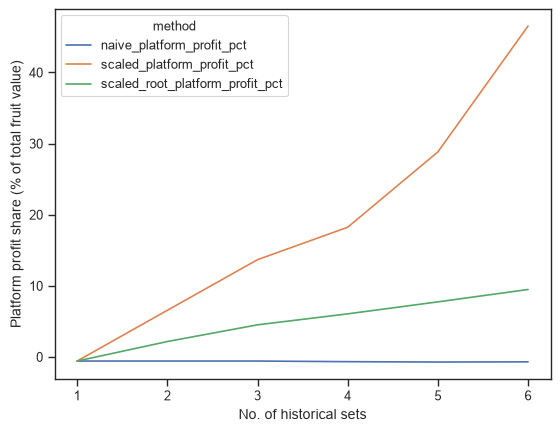

In [57]:
melted = df.melt(
    id_vars = "n_hist_sets",
    value_vars = ["naive_platform_profit_pct", "scaled_platform_profit_pct", "scaled_root_platform_profit_pct"],
    var_name  = "method",
    value_name = "platform_profit"
)

sns.lineplot(
    melted,
    x="n_hist_sets",
    y="platform_profit",
    hue="method"
)

plt.ylabel("Platform profit share (% of total fruit value)")
plt.xlabel("No. of historical sets")

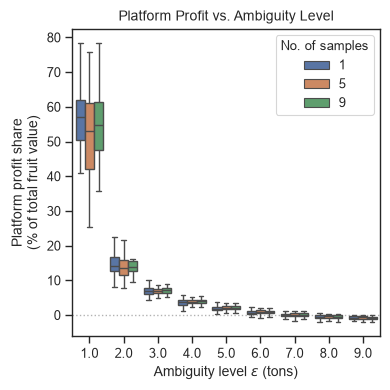

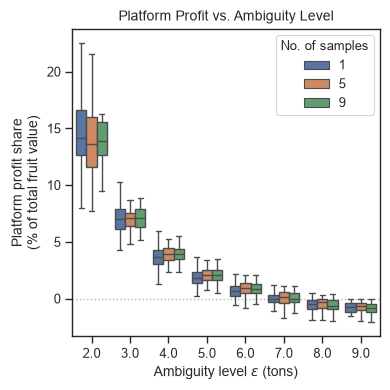

In [137]:
plt.figure(figsize=(4, 4))

ax = sns.boxplot(
    data=df.query("n_hist_sets in [1, 5, 9]"),
    x="avg_epsilon",
    y="platform_profit_pct",
    hue="n_hist_sets",
    showfliers=False,
    palette='deep',
)

plt.axhline(0, color="black", linestyle="dotted", linewidth=1, alpha=0.3, zorder=0)

plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.ylabel("Platform profit share\n(% of total fruit value)")
plt.title("Platform Profit vs. Ambiguity Level")
plt.legend(title="No. of samples")

plt.tight_layout()
plt.savefig("../figures/exp_5/platform_profit_samples.png", bbox_inches='tight', dpi=300)
plt.show()

plt.figure(figsize=(4, 4))

ax = sns.boxplot(
    data=df.query("n_hist_sets in [1, 5, 9] and avg_epsilon >= 2"),
    x="avg_epsilon",
    y="platform_profit_pct",
    hue="n_hist_sets",
    showfliers=False,
    palette='deep',
)

plt.axhline(0, color="black", linestyle="dotted", linewidth=1, alpha=0.3, zorder=0)

plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.ylabel("Platform profit share\n(% of total fruit value)")
plt.title("Platform Profit vs. Ambiguity Level")
plt.legend(title="No. of samples")

plt.tight_layout()
plt.savefig("../figures/exp_5/platform_profit_samples_restr.png", bbox_inches='tight', dpi=300)
plt.show()

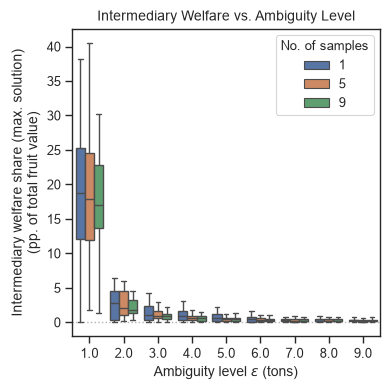

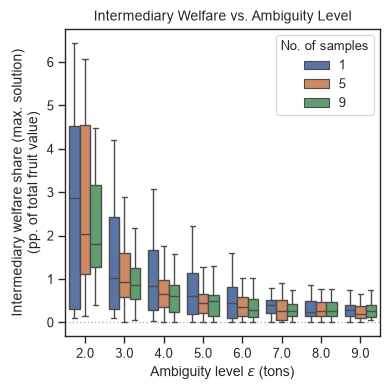

In [138]:
plt.figure(figsize=(4, 4))

ax = sns.boxplot(
    data=df.query("n_hist_sets in [1, 5, 9]"),
    x="avg_epsilon",
    y="max_intermediary_welfare_pct",
    hue="n_hist_sets",
    palette='deep',
    showfliers=False
)

plt.axhline(0, color="black", linestyle="dotted", linewidth=1, alpha=0.3, zorder=0)

plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.ylabel("Intermediary welfare share (max. solution)\n(pp. of total fruit value)")
plt.title("Intermediary Welfare vs. Ambiguity Level")
plt.legend(title="No. of samples")

plt.tight_layout()
plt.savefig("../figures/exp_5/intermediary_welfare_samples.png", bbox_inches='tight', dpi=300)
plt.show()

plt.figure(figsize=(4, 4))

ax = sns.boxplot(
    data=df.query("n_hist_sets in [1, 5, 9] and avg_epsilon >= 2"),
    x="avg_epsilon",
    y="max_intermediary_welfare_pct",
    hue="n_hist_sets",
    palette='deep',
    showfliers=False
)

plt.axhline(0, color="black", linestyle="dotted", linewidth=1, alpha=0.3, zorder=0)

plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.ylabel("Intermediary welfare share (max. solution)\n(pp. of total fruit value)")
plt.title("Intermediary Welfare vs. Ambiguity Level")
plt.legend(title="No. of samples")

plt.tight_layout()
plt.savefig("../figures/exp_5/intermediary_welfare_samples_restr.png", bbox_inches='tight', dpi=300)
plt.show()


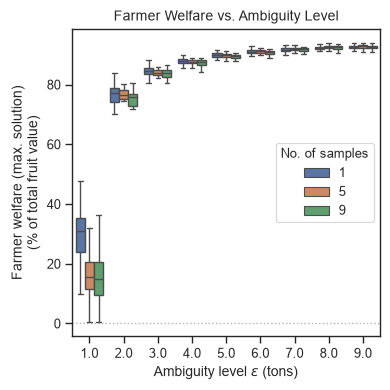

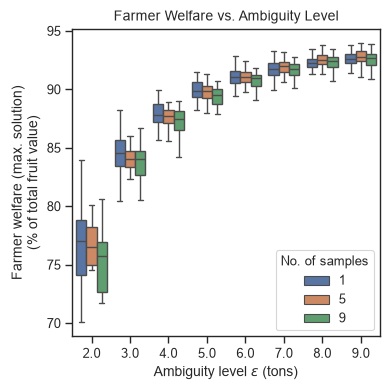

In [140]:
plt.figure(figsize=(4, 4))

ax = sns.boxplot(
    data=df.query("n_hist_sets in [1, 5, 9]"),
    x="avg_epsilon",
    y="max_farmer_welfare_pct",
    hue="n_hist_sets",
    showfliers=False,
    palette='deep',
)

plt.axhline(0, color="black", linestyle="dotted", linewidth=1, alpha=0.3, zorder=0)

plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.ylabel("Farmer welfare (max. solution)\n(% of total fruit value)")
plt.title("Farmer Welfare vs. Ambiguity Level")
plt.legend(title="No. of samples")

plt.tight_layout()

plt.savefig("../figures/exp_5/farmer_welfar_samples.png", bbox_inches='tight', dpi=300)
plt.show()


plt.figure(figsize=(4, 4))

ax = sns.boxplot(
    data=df.query("n_hist_sets in [1, 5, 9] and avg_epsilon >= 2"),
    x="avg_epsilon",
    y="max_farmer_welfare_pct",
    hue="n_hist_sets",
    showfliers=False,
    palette='deep',
)


plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.ylabel("Farmer welfare (max. solution)\n(% of total fruit value)")
plt.title("Farmer Welfare vs. Ambiguity Level")
plt.legend(title="No. of samples")

plt.tight_layout()

plt.savefig("../figures/exp_5/farmer_welfar_samples_restr.png", bbox_inches='tight', dpi=300)
plt.show()
